# Phase 5 — Notebook 17: KS Drift Monitor + Trigger (Objective 5)

The operational controller: a **label-free** monitor that decides *when* to act.
It compares each window's feature marginals to a held-out reference with the
two-sample KS statistic, aggregates to a per-window drift score, and **fires**
when the score crosses a reference-calibrated threshold. We then score those
triggers against the known novel-family onsets: **detection latency** and
**false-alarm rate**.

Scope: this notebook **does not retrain** — it only produces and characterises the
trigger. The retraining loop and the cumulative-buffer ceiling (carried forward
from notebook 16) belong to notebook 18. The monitor is written to
`src/monitoring/ks_monitor.py` so notebook 18 drives retraining from one trigger.

This directly operationalises **C2**: if the cheap label-free KS signal is an
adequate trigger, no explanation-based drift localisation is needed to decide when
to adapt.

## Pre-registration (D035)

**Monitor (label-free).** Reference = a held-out 40% split of the training
distribution (Monday+Tuesday). Per window, drift score = **mean per-feature KS**
statistic (window vs reference). Every KS comparison uses the full reference and
the full 50k-flow window — no subsampling.

**Threshold (reference-calibrated, label-free).** A disjoint 30% calibration split
of training is partitioned into windows; the null drift-score distribution gives
`tau = mu_null + K_SIGMA * sigma_null` (a `K_SIGMA`-sigma control-chart rule).

**Trigger.** Fire in window i iff `drift_score[i] > tau`.

**Monitored stream.** A disjoint 30% null-monitoring split of training (the
**quiet period**, in-distribution) followed by the full Wednesday–Friday replay
(the **drift period**), in order. The three training splits (reference /
calibration / null-monitoring) are disjoint so detection and false alarms are
assessed on data the threshold never saw.

**Ground truth (labels used only to score the monitor).** A window is a *drift
window* iff it contains attack families absent from training (`novel_rate > 0`); an
*onset* is the first window in which each new novel family appears.

**Metrics.** Detection rate over drift windows, false-alarm rate over the quiet
period, precision, and per-onset detection latency (windows).

**Gates** (verdict `KS-TRIGGER-VALID` iff all hold):

- **G1 — detection:** every novel-family onset detected within `L_MAX` windows
  **and** detection rate `>= DET_MIN`.
- **G2 — few false alarms:** false-alarm rate over the quiet period `<= FA_MAX`.
- **G3 — separation:** mean drift score on drift windows `> tau >` mean drift score
  on non-drift windows.
- **G4 — deterministic:** the score is reproducible under the fixed seed.

Thresholds are fixed before running; a failing gate is reported, not tuned away.

In [1]:
# --- Environment ---
import sys
from pathlib import Path
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass

THESIS_ROOT = Path('/content/drive/MyDrive/phd_thesis')
if str(THESIS_ROOT) not in sys.path:
    sys.path.insert(0, str(THESIS_ROOT))

import numpy as np, pandas as pd, json, time
from datetime import date
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

from src.utils.seeding import set_global_seed
from src.utils.io import path
from src.data.loaders import load_cicids2017
from src.utils.documentation import log_finding

SEED = 42
set_global_seed(SEED)

# --- Pre-registered configuration (D035) ---
WINDOW_SIZE = 50_000
TRAIN_DAYS  = ['monday', 'tuesday']
STREAM_DAYS = ['wednesday', 'thursday', 'friday']
REF_FRAC, CAL_FRAC, NULL_FRAC = 0.40, 0.30, 0.30   # disjoint training splits
K_SIGMA = 3.0       # control-chart threshold
L_MAX   = 1         # max acceptable detection latency (windows)
DET_MIN = 0.80      # min detection rate over drift windows
FA_MAX  = 0.10      # max false-alarm rate over the quiet period
print('Config set. SEED =', SEED)

Mounted at /content/drive
Config set. SEED = 42


In [2]:
# --- Load, split training into disjoint REF / CAL / NULL, build the stream ---
def load_days(days):
    Xs, ms = [], []
    for d in days:
        X, _y, meta = load_cicids2017(day=d)
        Xs.append(X.astype('float32'))
        ms.append(meta)
    X = pd.concat(Xs, ignore_index=True).reset_index(drop=True)
    meta = pd.concat(ms, ignore_index=True).reset_index(drop=True)
    return X, meta

def families(meta):
    return meta['attack_category'].astype(str).str.lower().to_numpy()

def windows_of(n, size):
    b = list(range(0, n, size)) + [n]
    return [(b[i], b[i + 1]) for i in range(len(b) - 1)]

# Training pool -> disjoint splits (seeded, representative)
X_tr, meta_tr = load_days(TRAIN_DAYS)
train_families = set(np.unique(families(meta_tr))) - {'benign'}
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(X_tr))
n_ref = int(REF_FRAC * len(X_tr)); n_cal = int(CAL_FRAC * len(X_tr))
idx_ref  = perm[:n_ref]
idx_cal  = perm[n_ref:n_ref + n_cal]
idx_null = perm[n_ref + n_cal:]

REF = X_tr.to_numpy()[idx_ref]
Xcal = X_tr.to_numpy()[idx_cal]
Xnull = X_tr.to_numpy()[idx_null]
fam_null = families(meta_tr)[idx_null]

# Stream (drift period)
X_st, meta_st = load_days(STREAM_DAYS)
assert list(X_tr.columns) == list(X_st.columns), 'feature schema mismatch'
Xstream = X_st.to_numpy()
fam_stream = families(meta_st)

cal_windows  = windows_of(len(Xcal), WINDOW_SIZE)
null_windows = windows_of(len(Xnull), WINDOW_SIZE)
strm_windows = windows_of(len(Xstream), WINDOW_SIZE)

print(f'Training rows {len(X_tr):,} -> REF {len(REF):,}, CAL {len(Xcal):,} '
      f'({len(cal_windows)} win), NULL {len(Xnull):,} ({len(null_windows)} win)')
print(f'Stream rows {len(Xstream):,} -> {len(strm_windows)} windows')
print('Training families (seen):', sorted(train_families))

Training rows 693,699 -> REF 277,479, CAL 208,109 (5 win), NULL 208,111 (5 win)
Stream rows 1,406,272 -> 29 windows
Training families (seen): ['ftp-patator', 'ssh-patator']


In [3]:
# --- Promote the monitor to src/monitoring/ks_monitor.py (shared by nb 18) ---
mon_dir = THESIS_ROOT / 'src' / 'monitoring'
mon_dir.mkdir(parents=True, exist_ok=True)
(mon_dir / '__init__.py').write_text(
    'from .ks_monitor import KSMonitor, per_feature_ks\n')

monitor_lines = [
    '"""',
    'KS drift monitor for the Phase-5 operational adaptation study (Objective 5).',
    '',
    "A label-free monitor: it compares each incoming window's feature marginals to a",
    "fixed reference (a held-out half of the detector's training distribution) with",
    'the two-sample Kolmogorov-Smirnov statistic, aggregates to a per-window drift',
    'score (mean KS across features), and fires when the score exceeds a',
    'reference-calibrated threshold tau = mu_null + k * sigma_null (a k-sigma',
    'control-chart rule). No labels are used by the monitor; labels enter only when',
    'its triggers are scored against novel-family onsets in the notebook.',
    '',
    'Promoted from notebook 17 so notebook 18 drives retraining from one trigger.',
    '"""',
    'from __future__ import annotations',
    'import numpy as np',
    'from scipy.stats import ks_2samp',
    '',
    '',
    'def per_feature_ks(reference, window):',
    '    """Per-feature two-sample KS statistics (reference vs window)."""',
    '    R = np.asarray(reference)',
    '    W = np.asarray(window)',
    '    out = np.empty(R.shape[1], dtype=float)',
    '    for j in range(R.shape[1]):',
    '        out[j] = ks_2samp(R[:, j], W[:, j]).statistic',
    '    return np.nan_to_num(out)',
    '',
    '',
    'class KSMonitor:',
    '    """Label-free KS drift monitor with a reference-calibrated trigger."""',
    '',
    '    def __init__(self, reference):',
    '        self.reference = np.asarray(reference)',
    '        self.tau = None',
    '        self.calibration = None',
    '',
    '    def drift_score(self, window):',
    '        """Window drift score = mean per-feature KS vs the reference."""',
    '        ks = per_feature_ks(self.reference, window)',
    '        return float(ks.mean()), ks',
    '',
    '    def calibrate(self, cal_windows, k=3.0):',
    '        """Set tau from in-distribution windows: tau = mu + k * sigma."""',
    '        scores = [self.drift_score(cw)[0] for cw in cal_windows]',
    '        mu = float(np.mean(scores))',
    '        sd = float(np.std(scores))',
    '        self.tau = mu + k * sd',
    '        self.calibration = dict(mu=mu, sd=sd, k=k, tau=self.tau,',
    '                                null_scores=[float(s) for s in scores])',
    '        return self.calibration',
    '',
    '    def fired(self, score):',
    '        if self.tau is None:',
    "            raise RuntimeError('call calibrate() before fired()')",
    '        return bool(score > self.tau)',
    ''
]
monitor_src = '\n'.join(monitor_lines)
(mon_dir / 'ks_monitor.py').write_text(monitor_src)

import importlib
import src.monitoring.ks_monitor as _m
importlib.reload(_m)
from src.monitoring.ks_monitor import KSMonitor
print(f'Wrote src/monitoring/ks_monitor.py ({len(monitor_lines)} lines) and imported it.')

Wrote src/monitoring/ks_monitor.py (56 lines) and imported it.


In [4]:
# --- Calibrate the threshold on the disjoint CAL split ---
monitor = KSMonitor(REF)
t0 = time.time()
calib = monitor.calibrate([Xcal[a:b] for (a, b) in cal_windows], k=K_SIGMA)
print(f'Calibrated in {time.time() - t0:.1f}s')
print(f"null mu={calib['mu']:.4f}  sigma={calib['sd']:.4f}  "
      f"K={K_SIGMA}  ->  tau={calib['tau']:.4f}")

Calibrated in 12.6s
null mu=0.0042  sigma=0.0026  K=3.0  ->  tau=0.0119


In [5]:
# --- Monitor the quiet period (NULL) then the drift period (stream) ---
def novel_rate(fam_slice):
    return float(np.mean([(f not in train_families) and (f != 'benign')
                          for f in fam_slice]))

records = []
t0 = time.time()
# quiet period
for (a, b) in null_windows:
    s, _ = monitor.drift_score(Xnull[a:b])
    records.append(dict(region='quiet', drift_score=s,
                        novel_rate=novel_rate(fam_null[a:b])))
# drift period
for (a, b) in strm_windows:
    s, _ = monitor.drift_score(Xstream[a:b])
    records.append(dict(region='drift', drift_score=s,
                        novel_rate=novel_rate(fam_stream[a:b])))

mon = pd.DataFrame(records)
mon.insert(0, 'window', range(len(mon)))
mon['fired'] = mon['drift_score'] > monitor.tau
mon['is_drift'] = mon['novel_rate'] > 0.0
print(f'Monitored {len(mon)} windows in {time.time() - t0:.1f}s')

# Novel-family onsets across the monitored sequence (drift period only)
seen = set(train_families)
onset_window = {}
row = 0
for (a, b) in null_windows:
    row += 1  # quiet windows never introduce novel families
for (a, b) in strm_windows:
    present = set(f for f in fam_stream[a:b] if f != 'benign')
    for fam in sorted(present - seen):
        onset_window[fam] = row
    seen |= present
    row += 1
mon['is_onset'] = mon['window'].isin(set(onset_window.values()))
print('Novel-family onsets (family -> window):', onset_window)

Monitored 34 windows in 109.6s
Novel-family onsets (family -> window): {'dos hulk': 5, 'dos slowhttptest': 5, 'dos slowloris': 5, 'dos goldeneye': 8, 'heartbleed': 9, 'web attack - brute force': 15, 'infiltration': 16, 'infiltration - portscan': 16, 'web attack - sql injection': 17, 'web attack - xss': 17, 'botnet': 22, 'ddos': 23, 'portscan': 23}


In [6]:
# --- Metrics, pre-registered gates, saved outputs ---
fired = mon['fired'].to_numpy()
is_drift = mon['is_drift'].to_numpy()
quiet = (mon['region'] == 'quiet').to_numpy()

tp = int((fired & is_drift).sum())
fn = int((~fired & is_drift).sum())
fp = int((fired & ~is_drift).sum())
detection_rate = tp / (tp + fn) if (tp + fn) else float('nan')
precision = tp / (tp + fp) if (tp + fp) else float('nan')
fa_rate_quiet = float(mon.loc[quiet, 'fired'].mean()) if quiet.any() else float('nan')

# Per-onset detection latency (windows from onset to first fire at/after it)
fired_idx = set(mon.loc[mon['fired'], 'window'].tolist())
latencies = {}
for fam, w0 in onset_window.items():
    later = [w for w in fired_idx if w >= w0]
    latencies[fam] = (min(later) - w0) if later else None
detected = {f: l for f, l in latencies.items() if l is not None}
mean_latency = float(np.mean(list(detected.values()))) if detected else float('nan')
all_onsets_in_LMAX = bool(onset_window) and all(
    (l is not None and l <= L_MAX) for l in latencies.values())

mean_score_drift = float(mon.loc[is_drift, 'drift_score'].mean()) if is_drift.any() else float('nan')
mean_score_nodrift = float(mon.loc[~is_drift, 'drift_score'].mean()) if (~is_drift).any() else float('nan')

# Determinism (G4): recompute one window's score
s_a, _ = monitor.drift_score(Xstream[strm_windows[0][0]:strm_windows[0][1]])
s_b, _ = monitor.drift_score(Xstream[strm_windows[0][0]:strm_windows[0][1]])
g4_determ = bool(abs(s_a - s_b) < 1e-12)

g1_detection = bool(all_onsets_in_LMAX and (detection_rate >= DET_MIN))
g2_false_alarm = bool((not np.isnan(fa_rate_quiet)) and fa_rate_quiet <= FA_MAX)
g3_separation = bool(mean_score_drift > monitor.tau > mean_score_nodrift)
verdict = ('KS-TRIGGER-VALID'
           if (g1_detection and g2_false_alarm and g3_separation and g4_determ)
           else 'KS-TRIGGER-CHECK-FAILED')

summary = dict(
    notebook='17_ks_trigger', decision='D035', finding='F023',
    generated=str(date.today()), seed=SEED, dataset='CICIDS2017',
    window_size=WINDOW_SIZE, train_days=TRAIN_DAYS, stream_days=STREAM_DAYS,
    splits=dict(ref_frac=REF_FRAC, cal_frac=CAL_FRAC, null_frac=NULL_FRAC),
    calibration=calib, K_SIGMA=K_SIGMA, tau=monitor.tau,
    n_windows_total=len(mon), n_quiet=int(quiet.sum()),
    n_drift_windows=int(is_drift.sum()), n_fired=int(fired.sum()),
    detection_rate=detection_rate, precision=precision,
    false_alarm_rate_quiet=fa_rate_quiet,
    onsets=onset_window, latencies=latencies, mean_latency=mean_latency,
    mean_score_drift=mean_score_drift, mean_score_nodrift=mean_score_nodrift,
    gates=dict(g1_detection=g1_detection, g2_false_alarm=g2_false_alarm,
               g3_separation=g3_separation, g4_determinism=g4_determ,
               L_MAX=L_MAX, DET_MIN=DET_MIN, FA_MAX=FA_MAX),
    verdict=verdict,
)

path('reports', 'tables').mkdir(parents=True, exist_ok=True)
path('data', 'processed').mkdir(parents=True, exist_ok=True)
mon.to_csv(path('reports', 'tables', '17_ks_trigger.csv'), index=False)
with open(path('data', 'processed', 'phase5_17_ks_trigger.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "notebook": "17_ks_trigger",
  "decision": "D035",
  "finding": "F023",
  "generated": "2026-06-12",
  "seed": 42,
  "dataset": "CICIDS2017",
  "window_size": 50000,
  "train_days": [
    "monday",
    "tuesday"
  ],
  "stream_days": [
    "wednesday",
    "thursday",
    "friday"
  ],
  "splits": {
    "ref_frac": 0.4,
    "cal_frac": 0.3,
    "null_frac": 0.3
  },
  "calibration": {
    "mu": 0.004202275314750346,
    "sd": 0.002562658089905156,
    "k": 3.0,
    "tau": 0.011890249584465815,
    "null_scores": [
      0.002968040829106029,
      0.0032798877893550045,
      0.0023726839139397923,
      0.0030994495650253037,
      0.009291314476325599
    ]
  },
  "K_SIGMA": 3.0,
  "tau": 0.011890249584465815,
  "n_windows_total": 34,
  "n_quiet": 5,
  "n_drift_windows": 29,
  "n_fired": 29,
  "detection_rate": 1.0,
  "precision": 1.0,
  "false_alarm_rate_quiet": 0.0,
  "onsets": {
    "dos hulk": 5,
    "dos slowhttptest": 5,
    "dos slowloris": 5,
    "dos goldeneye": 8,
    "

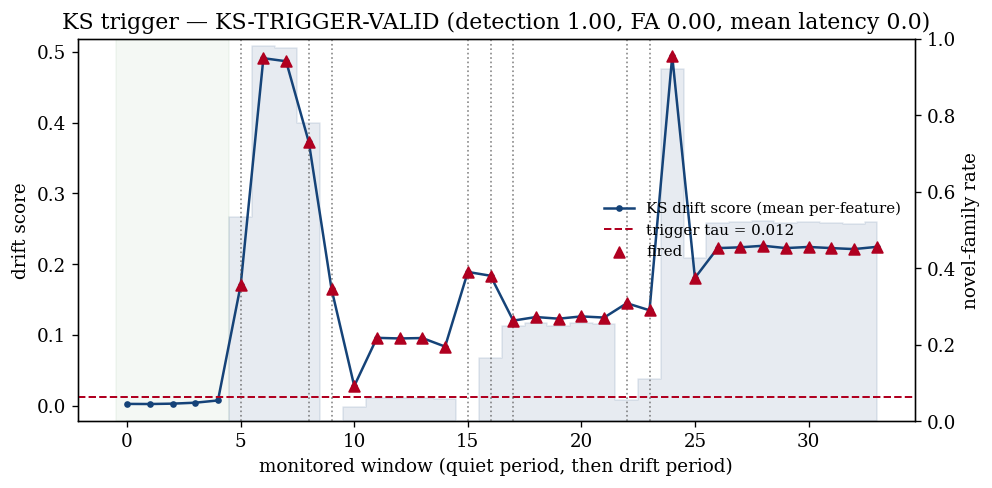

In [7]:
# --- Figure: drift score, threshold, onsets, fires, novel-family rate ---
plt.rcParams.update({'font.family': 'serif', 'font.size': 11,
                     'figure.dpi': 120, 'savefig.dpi': 300})
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax2 = ax.twinx()
ax2.fill_between(mon['window'], 0, mon['novel_rate'], step='mid',
                 alpha=0.10, color='#154378')
ax2.set_ylabel('novel-family rate'); ax2.set_ylim(0, 1)

ax.plot(mon['window'], mon['drift_score'], '-o', ms=3, lw=1.5,
        color='#154378', label='KS drift score (mean per-feature)')
ax.axhline(monitor.tau, ls='--', lw=1.2, color='#B00020',
           label=f'trigger tau = {monitor.tau:.3f}')
fired_pts = mon[mon['fired']]
ax.scatter(fired_pts['window'], fired_pts['drift_score'], s=42, marker='^',
           color='#B00020', zorder=5, label='fired')
qmax = int((mon['region'] == 'quiet').sum())
ax.axvspan(-0.5, qmax - 0.5, color='#2E7D32', alpha=0.05)  # quiet-period shade
for w0 in sorted(set(onset_window.values())):
    ax.axvline(w0, ls=':', lw=1.0, color='#555555', alpha=0.7)
ax.set_xlabel('monitored window (quiet period, then drift period)')
ax.set_ylabel('drift score')
ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)
ax.set_title(f'KS trigger — {verdict} '
             f'(detection {detection_rate:.2f}, FA {fa_rate_quiet:.2f}, '
             f'mean latency {mean_latency:.1f})')
ax.legend(loc='center right', frameon=False, fontsize=9)
fig.tight_layout()
path('reports', 'figures').mkdir(parents=True, exist_ok=True)
for ext in ('png', 'pdf'):
    fig.savefig(path('reports', 'figures', f'17_ks_trigger.{ext}'), bbox_inches='tight')
plt.show()

In [8]:
# --- Log decision D035 (idempotent append) and finding F023 ---
dec_path = path('reports', 'advisor_notes', 'decisions_log.md')
dec_path.parent.mkdir(parents=True, exist_ok=True)
dec_lines = [
    '',
    f'## D035 — {date.today()}',
    '**Context:** `07_phase5_adaptation/17_ks_trigger`',
    '',
    ('**Decision:** Define the Objective-5 label-free KS drift monitor and trigger on the '
     'CICIDS stream. Reference = a held-out 40% split of the training distribution '
     '(Monday+Tuesday); per-window drift score = mean per-feature two-sample KS statistic vs '
     'the reference (full reference, full 50k window, no subsampling). Threshold = '
     f'tau = mu_null + {K_SIGMA}*sigma_null, calibrated on a disjoint 30% calibration split '
     'partitioned into windows. Trigger fires when score > tau. Monitored stream = a disjoint '
     '30% null-monitoring split (quiet period) followed by the full Wednesday-Friday replay '
     '(drift period); the three training splits are disjoint so detection and false alarms '
     'are assessed on data the threshold never saw. Ground truth (labels used only to score '
     'the monitor): drift window iff novel_rate > 0; onset = first window of each new novel '
     f'family. Gates: G1 every onset detected within {L_MAX} window AND detection rate >= '
     f'{DET_MIN}; G2 false-alarm rate over the quiet period <= {FA_MAX}; G3 mean drift-window '
     'score > tau > mean non-drift score; G4 deterministic. Verdict KS-TRIGGER-VALID iff all. '
     'Monitor written to src/monitoring/ks_monitor.py for notebook 18.'),
    '',
    ('**Rationale:** Objective 5 is the controller that decides when to adapt. The thesis (C2) '
     'already showed label-free KS is competitive with explanation-based drift localisation, '
     'so the disciplined design uses KS itself as the trigger and asks the operational '
     'questions that matter: does it detect the drift, how fast, and how often does it false '
     'alarm. A reference-calibrated k-sigma threshold is label-free and standard. Splitting '
     'training into disjoint reference/calibration/null sets makes false-alarm and detection '
     'estimates honest. Monitoring a quiet period before the drift period gives the trigger a '
     'fair chance to false-alarm, which the drift-dominated replay alone would not.'),
    '',
    ('**Alternatives considered:** Sliding-reference (consecutive-window) KS change-point '
     '(rejected as primary: misses persistent drift away from the training distribution, which '
     'is what degrades the detector). Fixed absolute KS threshold (rejected: not calibrated to '
     'the data). Max or breadth aggregation instead of mean KS (recorded as sensitivities; mean '
     'is the pre-registered primary). Persistence-2 trigger (single-window trigger pre-registered; '
     'persistence can be revisited in nb 18 if false alarms are high). The cumulative-buffer '
     'ceiling carried forward from nb 16 is deferred to nb 18, where retraining lives.'),
    '',
]
dec_text = '\n'.join(dec_lines) + '\n'
existing = dec_path.read_text() if dec_path.exists() else ''
if '## D035' in existing:
    print('[DECISION SKIPPED] D035 already logged.')
else:
    with open(dec_path, 'a') as f:
        f.write(dec_text)
    print('[DECISION LOGGED] D035')

log_finding(
    finding_id='F023',
    title='Label-free KS trigger characterised on the CICIDS stream (Objective 5)',
    what_we_did=(
        'Built the Objective-5 label-free KS drift monitor (src/monitoring/ks_monitor.py) and '
        'pre-registered it (D035): mean per-feature KS vs a held-out reference, a 3-sigma '
        'reference-calibrated trigger, monitored over a quiet (in-distribution) period then the '
        'full Wednesday-Friday drift period, scored against novel-family onsets.'),
    what_we_found=(
        f'Verdict {verdict}. tau={monitor.tau:.4f}. Detection rate over drift windows '
        f'{detection_rate:.3f}; false-alarm rate over the quiet period {fa_rate_quiet:.3f}; '
        f'precision {precision:.3f}; mean per-onset detection latency {mean_latency:.2f} '
        f'windows over {len(onset_window)} onsets. Mean drift score {mean_score_drift:.3f} on '
        f'drift windows vs {mean_score_nodrift:.3f} on non-drift. Gates G1={g1_detection}, '
        f'G2={g2_false_alarm}, G3={g3_separation}, G4={g4_determ}.'),
    why_it_matters=(
        'Establishes whether the cheap label-free KS signal is an adequate operational trigger '
        '(Objective 5) and quantifies its latency and false-alarm cost. This is the controller '
        'notebook 18 uses to decide when to spend a label budget on retraining, and it '
        'operationalises C2: no explanation-based localisation is needed to decide when to adapt.'),
    context='07_phase5_adaptation/17_ks_trigger',
)
print('Done.')

[DECISION LOGGED] D035
[FINDING LOGGED] F023: Label-free KS trigger characterised on the CICIDS stream (Objective 5)
Done.


## What this notebook establishes

- A reusable `KSMonitor` in `src/monitoring/ks_monitor.py` (label-free, calibrated trigger).
- The trigger's **operating characteristic** on the CICIDS stream: detection rate,
  false-alarm rate over a quiet period, precision, and per-onset **detection latency**.
- The pre-registered gate verdict.

Outputs: `reports/tables/17_ks_trigger.csv`,
`data/processed/phase5_17_ks_trigger.json`,
`reports/figures/17_ks_trigger.{png,pdf}`; logs D035 + F023.

**Honest caveat.** The monitor detects feature-distribution (P(X)) shift, which we score
against novel-family onset as a proxy for *drift that hurts detection*. A feature shift from
benign-traffic changes would count as a false alarm here even if it is a real distribution
shift — worth stating when this feeds the paper.

**Next — notebook 18 (`18_triggered_retraining`):** close the loop — when this trigger fires,
spend a label budget and retrain; compare signal-triggered vs fixed-schedule vs always- vs
never-retrain, and add the cumulative-buffer ceiling carried forward from notebook 16.